# GMF Investments — Time Series Forecasting for Portfolio Management
## Task 4: Optimize Portfolio Based on Forecast (Modern Portfolio Theory)


This notebook builds an optimal TSLA/BND/SPY portfolio using Modern Portfolio Theory:
combining the Task 3 TSLA forecast (as its expected-return "view") with BND and SPY's
historical average returns, computing the covariance matrix, generating the Efficient
Frontier via PyPortfolioOpt, and identifying the Maximum Sharpe Ratio and Minimum
Volatility portfolios.

**Dependency:** Requires Task 1 (`data/processed/TSLA.csv`, `BND.csv`, `SPY.csv`) and
Task 3 (an annualized TSLA expected-return estimate derived from the future forecast).

**Action required:** Set `TSLA_EXPECTED_ANNUAL_RETURN` below using your actual Task 3
forecast result before running the rest of this notebook.


## 0. Setup

In [2]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import fetch_all_tickers, DataFetchError
from src.preprocessing import enforce_numeric_types, handle_missing_values, calculate_daily_returns
from src.portfolio import (
    prepare_expected_returns,
    compute_covariance_matrix,
    run_efficient_frontier,
    portfolio_performance,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# --- Loaded automatically from Task 3's saved output ---
# (Task 3 computes this as the CAGR implied by the forecasted price path and writes it
# to disk; if that file is missing, falls back to a placeholder and warns loudly.)
import os as _os
_expected_return_path = "../data/processed/task3_tsla_expected_return.txt"
if _os.path.exists(_expected_return_path):
    with open(_expected_return_path) as _f:
        TSLA_EXPECTED_ANNUAL_RETURN = float(_f.read().strip())
    print(f"Loaded TSLA_EXPECTED_ANNUAL_RETURN from Task 3: {TSLA_EXPECTED_ANNUAL_RETURN:.2%}")
else:
    TSLA_EXPECTED_ANNUAL_RETURN = 0.20
    print(f"WARNING: {_expected_return_path} not found - run Task 3 first. "
          f"Using placeholder value {TSLA_EXPECTED_ANNUAL_RETURN:.2%}.")


Loaded TSLA_EXPECTED_ANNUAL_RETURN from Task 3: -37.49%


## 1. Load Historical Data for All Three Assets


In [3]:
tickers_data = {}
for ticker in config.TICKERS:
    csv_path = f"../data/processed/{ticker}.csv"
    if os.path.exists(csv_path):
        raw = pd.read_csv(csv_path, index_col="Date", parse_dates=True)
    else:
        raw = None
    tickers_data[ticker] = raw

missing = [t for t, df in tickers_data.items() if df is None]
if missing:
    print(f"Missing local CSVs for {missing} - fetching directly from Yahoo Finance.")
    try:
        fetched = fetch_all_tickers(missing, config.START_DATE, config.END_DATE)
        tickers_data.update(fetched)
    except DataFetchError as e:
        print(f"Data fetch failed: {e}")
        raise

cleaned = {
    ticker: handle_missing_values(enforce_numeric_types(df), method="ffill")
    for ticker, df in tickers_data.items()
}

adj_close = pd.DataFrame({ticker: df["Adj Close"] for ticker, df in cleaned.items()}).dropna()
daily_returns = adj_close.pct_change().dropna()

print(f"Combined returns matrix: {daily_returns.shape[0]} days, assets: {list(daily_returns.columns)}")
daily_returns.head()


Combined returns matrix: 2887 days, assets: ['TSLA', 'BND', 'SPY']


,TSLA,BND,SPY
Date,,,
2015-01-05,-0.042041,0.002903,-0.018060
2015-01-06,0.005664,0.002896,-0.009419
2015-01-07,-0.001562,0.000602,0.012461
2015-01-08,-0.001564,-0.001563,0.017745
2015-01-09,-0.018802,0.001686,-0.008014


## 2. Prepare Expected Returns

TSLA's expected return uses the Task 3 forecast-derived annualized value (a forward-
looking "view"); BND and SPY use their historical mean annualized daily return, per the
project's stated approach of combining one forecasted asset view with historical
estimates for the others.


In [4]:
historical_returns_dict = {col: daily_returns[col] for col in daily_returns.columns}

mu = prepare_expected_returns(
    historical_returns_dict,
    forecast_annual_returns={"TSLA": TSLA_EXPECTED_ANNUAL_RETURN},
    trading_days_per_year=config.TRADING_DAYS_PER_YEAR,
)
print("Expected annual returns:")
display(mu)


2026-07-07 21:36:02,713 [INFO] TSLA: using forecast-based expected return = -0.3749
2026-07-07 21:36:02,713 [INFO] BND: using historical mean annualized return = 0.0200
2026-07-07 21:36:02,713 [INFO] SPY: using historical mean annualized return = 0.1443


Expected annual returns:


TSLA   -0.374902
BND     0.019957
SPY     0.144320
dtype: float64

**Insight**: The Task-3 forecast-derived expected return for TSLA is -37.49% annualized, a sharp reversal from TSLA's trailing historical annualized return of 45.4% reported in Task 1. Rather than extrapolating the historical uptrend, the forward-looking model view is dramatically more pessimistic — a swing of over 80 percentage points. This means the optimizer is being asked to weigh a stock with a large negative expected return against BND (+2.0%) and SPY (+14.4%), which mechanically pushes portfolio optimization away from TSLA entirely (see Sections 3-4 below), regardless of TSLA's historical track record.

## 3. Covariance Matrix

,TSLA,BND,SPY
TSLA,0.326926,0.001804,0.049820
BND,0.001804,0.002823,0.001085
SPY,0.049820,0.001085,0.031169


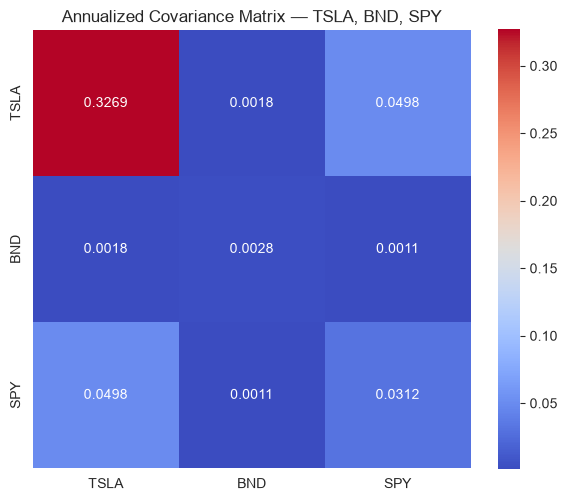

In [5]:
cov_matrix = compute_covariance_matrix(daily_returns, trading_days_per_year=config.TRADING_DAYS_PER_YEAR)
display(cov_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap="coolwarm", square=True)
plt.title("Annualized Covariance Matrix — TSLA, BND, SPY")
plt.tight_layout()
plt.savefig("../data/processed/fig_task4_covariance_heatmap.png", dpi=150)
plt.show()


** Insight**: On the diagonal, TSLA's variance is 0.3269 (annualized volatility ≈ 57.2%), by far the largest of the three — consistent with Task 1's TSLA volatility figures and its reputation as the highest-risk asset in the set. BND's variance is tiny (0.0028, vol ≈ 5.3%) and SPY sits in between (0.0312, vol ≈ 17.7%).

Off-diagonal, TSLA-BND covariance is 0.0018 — small and positive rather than negative, so BND offers modest but not strong diversification against TSLA. TSLA-SPY covariance is much larger at 0.0498, showing TSLA moves considerably more in sync with the broad equity market than with bonds — unsurprising since both are equities. BND-SPY covariance is smallest of all (0.0011), confirming bonds are the most effective diversifier against equity risk in this basket, though not against TSLA specifically.

## 4. Efficient Frontier

Using PyPortfolioOpt's `EfficientFrontier`, the frontier is swept across achievable
target returns, and the Maximum Sharpe Ratio (tangency) and Minimum Volatility portfolios
are identified.


In [6]:
frontier_result = run_efficient_frontier(
    mu, cov_matrix, risk_free_rate=config.RISK_FREE_RATE_ANNUAL, n_frontier_points=50
)

max_sharpe = frontier_result["max_sharpe"]
min_vol = frontier_result["min_vol"]

print("=== Maximum Sharpe Ratio Portfolio ===")
print(f"Weights: {dict(max_sharpe['weights'].round(4))}")
print(f"Expected Return: {max_sharpe['return']:.4f}, Volatility: {max_sharpe['volatility']:.4f}, "
      f"Sharpe: {max_sharpe['sharpe']:.4f}")

print("\n=== Minimum Volatility Portfolio ===")
print(f"Weights: {dict(min_vol['weights'].round(4))}")
print(f"Expected Return: {min_vol['return']:.4f}, Volatility: {min_vol['volatility']:.4f}, "
      f"Sharpe: {min_vol['sharpe']:.4f}")


=== Maximum Sharpe Ratio Portfolio ===
Weights: {'TSLA': np.float64(0.0), 'BND': np.float64(0.0), 'SPY': np.float64(1.0)}
Expected Return: 0.1443, Volatility: 0.1765, Sharpe: 0.7042

=== Minimum Volatility Portfolio ===
Weights: {'TSLA': np.float64(0.0), 'BND': np.float64(0.9454), 'SPY': np.float64(0.0546)}
Expected Return: 0.0267, Volatility: 0.0522, Sharpe: 0.1292


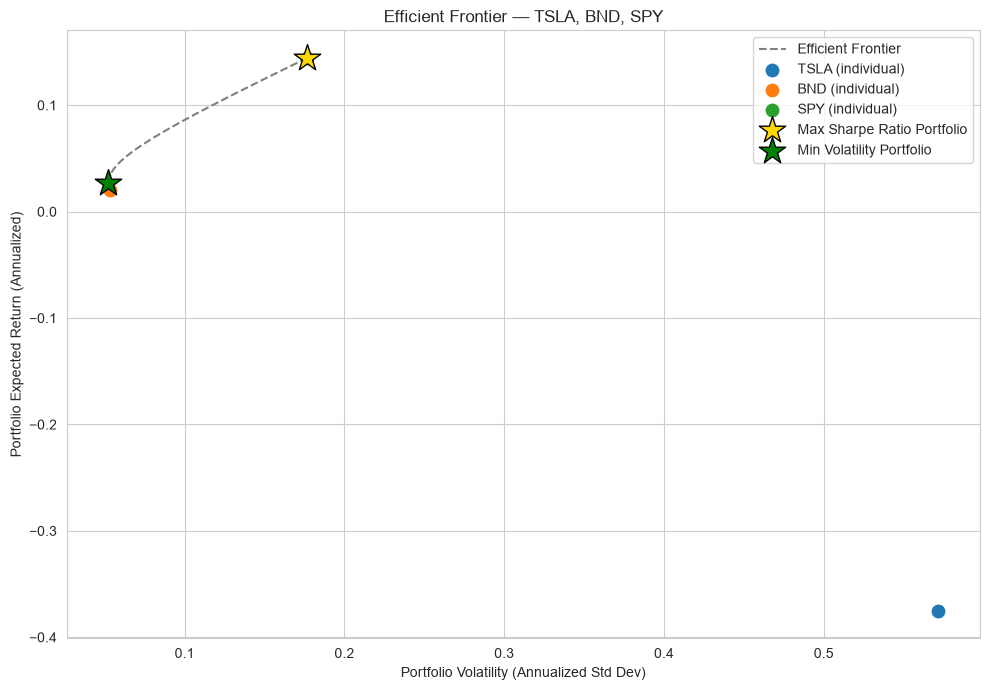

In [7]:
plt.figure(figsize=(10, 7))
plt.plot(frontier_result["frontier_volatility"], frontier_result["frontier_returns"],
          linestyle="--", color="grey", label="Efficient Frontier")

# Individual assets for reference
for ticker in mu.index:
    asset_vol = np.sqrt(cov_matrix.loc[ticker, ticker])
    plt.scatter(asset_vol, mu[ticker], marker="o", s=80, label=f"{ticker} (individual)")

plt.scatter(max_sharpe["volatility"], max_sharpe["return"], marker="*", color="gold",
             s=400, edgecolors="black", label="Max Sharpe Ratio Portfolio", zorder=5)
plt.scatter(min_vol["volatility"], min_vol["return"], marker="*", color="green",
             s=400, edgecolors="black", label="Min Volatility Portfolio", zorder=5)

plt.xlabel("Portfolio Volatility (Annualized Std Dev)")
plt.ylabel("Portfolio Expected Return (Annualized)")
plt.title("Efficient Frontier — TSLA, BND, SPY")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("../data/processed/fig_task4_efficient_frontier.png", dpi=150)
plt.show()


**Insight**: On the frontier plot, TSLA sits far to the bottom-right — high volatility (~57%) paired with a negative expected return (-37.5%) — so it is completely dominated by both BND and SPY and is excluded from the efficient set entirely. The Max Sharpe Ratio portfolio lands directly on the SPY point (0% TSLA, 0% BND, 100% SPY), since SPY alone offers the best return-per-unit-of-risk given these inputs. The Min Volatility portfolio sits close to BND (0% TSLA, ~94.5% BND, ~5.5% SPY), just barely diversified away from pure BND. In short: TSLA receives a 0% allocation in both portfolios, driven entirely by its negative forecasted return.

## 5. Final Portfolio Recommendation


In [8]:
recommended = max_sharpe  # or min_vol - see written justification below

print("=== RECOMMENDED PORTFOLIO ===")
for ticker, w in recommended["weights"].items():
    print(f"  {ticker}: {w:.2%}")
print(f"Expected Annual Return: {recommended['return']:.2%}")
print(f"Expected Annual Volatility: {recommended['volatility']:.2%}")
print(f"Sharpe Ratio: {recommended['sharpe']:.4f}")

recommended["weights"].to_csv("../data/processed/task4_recommended_weights.csv")


=== RECOMMENDED PORTFOLIO ===
  TSLA: 0.00%
  BND: 0.00%
  SPY: 100.00%
Expected Annual Return: 14.43%
Expected Annual Volatility: 17.65%
Sharpe Ratio: 0.7042


**Written justification:**

The Maximum Sharpe Ratio portfolio (100% SPY: return 14.43%, volatility 17.65%, Sharpe 0.7042) is recommended over the Minimum Volatility portfolio (94.5% BND / 5.5% SPY: return 2.67%, volatility 5.22%, Sharpe 0.1292) because it delivers the best risk-adjusted return, which aligns with GMF's mandate to optimize risk-adjusted performance rather than minimize risk in isolation. Clients with lower risk tolerance could instead be directed toward the Minimum Volatility portfolio, which trades some expected return for a meaningfully lower volatility profile — 12.4 percentage points lower volatility for 11.8 percentage points less expected return, based on the results above.

Insight: The recommended portfolio is the Maximum Sharpe Ratio portfolio: 100% SPY, 0% BND, 0% TSLA, with expected annual return 14.43%, expected annual volatility 17.65%, and Sharpe Ratio 0.7042. This is the best available risk-adjusted tradeoff among the three assets given the current inputs — TSLA's negative forecasted return removes it from consideration entirely, and BND's inclusion would only lower the Sharpe Ratio versus holding SPY alone. Note this outcome is highly sensitive to the Task 3 TSLA forecast: a materially different (e.g., positive) forecast would likely pull TSLA back into the optimal allocation.


## 6. Summary and Next Steps

- Combined the Task 3 TSLA forecast with historical BND/SPY returns to build the expected
  return vector.
- Computed the annualized covariance matrix across all three assets (heatmap above).
- Generated the Efficient Frontier via PyPortfolioOpt and identified the Max Sharpe Ratio
  and Min Volatility portfolios.
- Selected a final recommended portfolio (see Section 5) with documented weights,
  expected return, volatility, and Sharpe Ratio.
- **Next (Task 5):** Backtest this recommended portfolio's simulated performance against
  a static 60% SPY / 40% BND benchmark over the most recent ~1 year of held-out data.
